Importing the Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score , precision_score , recall_score , precision_recall_curve , confusion_matrix , auc , classification_report 
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib

Loading the data

In [2]:
X_train_scaled = pd.read_parquet('../data/processed/X_train_scaled.parquet')
X_val_scaled   = pd.read_parquet('../data/processed/X_val_scaled.parquet')
X_test_scaled  = pd.read_parquet('../data/processed/X_test_scaled.parquet')

X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_val   = pd.read_parquet('../data/processed/X_val.parquet')
X_test  = pd.read_parquet('../data/processed/X_test.parquet')

y_train = pd.read_parquet('../data/processed/y_train.parquet')['isFraud']
y_val   = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
y_test  = pd.read_parquet('../data/processed/y_test.parquet')['isFraud']

Creating an Evaluator Helper Function

In [3]:
# Performing full evaluation of the model , returning metrics deictionary and printing a clean summary

def evaluate_model(model , X , y , model_name , threshold= 0.5):
    proba = model.predict_proba(X)[ : , 1]   #returns 2D array with probabilty of fraud/not fraud ,[ : , 1] we only take fraud probabilty
    preds = (proba >= threshold).astype(int)        #converts probabilities to 0/1 predictions at your chosen threshold:

    # Metrics
    precision = precision_score(y , preds , zero_division=0)
    recall    = recall_score(y, preds, zero_division=0)
    f1        = f1_score(y, preds, zero_division=0)

    pr_precision , pr_recall , _ = precision_recall_curve(y , proba)
    pr_auc = auc(pr_recall, pr_precision) 

    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)                  # fraction of legitimate transactions we wrongly blocked

    print(f"Model: {model_name} , Threshold: {threshold}")
    print(f"Precision Recall AUC: {pr_auc:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"FPR:       {fpr:.4f}")
    print(f"{fpr*100:.2f}% legitimate transactions blocked")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {tp:,}  FP: {fp:,}")
    print(f"  FN: {fn:,}  TN: {tn:,}")

    return {
        'model_name': model_name,
        'threshold': threshold,
        'pr_auc': pr_auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fpr': fpr,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }

In [10]:
X_train_raw = pd.read_parquet('../data/processed/X_train_raw.parquet')
y_train_raw = pd.read_parquet('../data/processed/y_train_raw.parquet')['isFraud']

neg = (y_train_raw == 0).sum()
pos = (y_train_raw == 1).sum()
spw = neg / pos

print(f"Shape: {X_train_raw.shape}")
print(f"Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"scale_pos_weight: {spw:.2f}")

Shape: (354324, 216)
Fraud rate: 3.38%
scale_pos_weight: 28.56


Re running XGBoost default but on raw datasets

In [11]:
print("Training XGBoost default on raw (non-SMOTE) data...")

xgb_default = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # 28.56 — handles imbalance natively
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_default.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_default_metrics = evaluate_model(
    xgb_default , X_val, y_val , model_name="XGBoost Default (raw)" , threshold=0.5)

Training XGBoost default on raw (non-SMOTE) data...
Model: XGBoost Default (raw) , Threshold: 0.5
Precision Recall AUC: 0.5664
F1 score: 0.4271
Precision: 0.3113
Recall:    0.6803
FPR:       0.0633
6.33% legitimate transactions blocked

Confusion Matrix:
  TP: 2,432  FP: 5,381
  FN: 1,143  TN: 79,625


Running Optuna Hyperparameter tuning now 

In [12]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': spw,
        'eval_metric':      'aucpr',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_raw, y_train_raw,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    proba = model.predict_proba(X_val)[:, 1]
    pr_prec, pr_rec, _ = precision_recall_curve(y_val, proba)
    return auc(pr_rec, pr_prec)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Seed with default params as first trial
study_xgb.enqueue_trial({
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0
})

print("Running Optuna for XGBoost (50 trials)...")
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost PR-AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

[I 2026-06-10 10:19:47,026] A new study created in memory with name: no-name-d8fbaf78-08cb-4dc2-b244-68b32e953cb5


Running Optuna for XGBoost (50 trials)...


Best trial: 0. Best value: 0.566373:   2%|▏         | 1/50 [00:13<11:05, 13.57s/it]

[I 2026-06-10 10:20:00,620] Trial 0 finished with value: 0.566373022020713 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0}. Best is trial 0 with value: 0.566373022020713.


Best trial: 0. Best value: 0.566373:   4%|▍         | 2/50 [00:30<12:12, 15.27s/it]

...

[I 2026-06-10 10:33:28,456] Trial 47 finished with value: 0.566613413367414 and parameters: {'n_estimators': 204, 'max_depth': 9, 'learning_rate': 0.12672470088110932, 'subsample': 0.7074446243383796, 'colsample_bytree': 0.8690886207954589, 'min_child_weight': 7, 'gamma': 0.8208662906415345}. Best is trial 26 with value: 0.5841082948442594.


Best trial: 26. Best value: 0.584108:  98%|█████████▊| 49/50 [13:48<00:13, 13.40s/it]

[I 2026-06-10 10:33:35,480] Trial 48 finished with value: 0.5633224084427023 and parameters: {'n_estimators': 101, 'max_depth': 10, 'learning_rate': 0.15658186208866673, 'subsample': 0.9257824469438295, 'colsample_bytree': 0.7485861219973629, 'min_child_weight': 9, 'gamma': 1.6791644663778826}. Best is trial 26 with value: 0.5841082948442594.


Best trial: 26. Best value: 0.584108: 100%|██████████| 50/50 [13:56<00:00, 16.74s/it]

[I 2026-06-10 10:33:43,951] Trial 49 finished with value: 0.5334525902134593 and parameters: {'n_estimators': 176, 'max_depth': 5, 'learning_rate': 0.03898571256948453, 'subsample': 0.8654334280301261, 'colsample_bytree': 0.9658465130246872, 'min_child_weight': 8, 'gamma': 0.2873897420738205}. Best is trial 26 with value: 0.5841082948442594.

Best XGBoost PR-AUC: 0.5841
Best params: {'n_estimators': 275, 'max_depth': 9, 'learning_rate': 0.08784423028718466, 'subsample': 0.9520978812241658, 'colsample_bytree': 0.9106621066812718, 'min_child_weight': 9, 'gamma': 1.1307446836014143}


In [20]:
best_xgb_params = study_xgb.best_params
best_xgb_params

{'n_estimators': 275,
 'max_depth': 9,
 'learning_rate': 0.08784423028718466,
 'subsample': 0.9520978812241658,
 'colsample_bytree': 0.9106621066812718,
 'min_child_weight': 9,
 'gamma': 1.1307446836014143}

In [13]:
best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'scale_pos_weight': spw,
    'eval_metric':      'aucpr',
    'random_state':     42,
    'n_jobs':           -1,
    'verbosity':        0
})

xgb_best = xgb.XGBClassifier(**best_xgb_params)
xgb_best.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_best_metrics = evaluate_model(
    xgb_best, X_val, y_val,
    model_name="XGBoost Optuna",
    threshold=0.5
)

# Overfit check
train_metrics = evaluate_model(
    xgb_best, X_train_raw, y_train_raw,
    model_name="XGBoost Optuna (TRAIN)",
    threshold=0.5
)

Model: XGBoost Optuna , Threshold: 0.5
Precision Recall AUC: 0.5841
F1 score: 0.5059
Precision: 0.4311
Recall:    0.6120
FPR:       0.0340
3.40% legitimate transactions blocked

Confusion Matrix:
  TP: 2,188  FP: 2,887
  FN: 1,387  TN: 82,119
Model: XGBoost Optuna (TRAIN) , Threshold: 0.5
Precision Recall AUC: 0.9334
F1 score: 0.7019
Precision: 0.5516
Recall:    0.9647
FPR:       0.0275
2.75% legitimate transactions blocked

Confusion Matrix:
  TP: 11,565  FP: 9,401
  FN: 423  TN: 332,935


Even if AUC has lowered a little bit , precision and recall have drastically improved , so keeping these parameters only and finding the best threshold

In [16]:
proba_xgb = xgb_best.predict_proba(X_val)[:, 1]
pr_prec, pr_rec, thresholds = precision_recall_curve(y_val, proba_xgb)

f1_scores = 2 * (pr_prec * pr_rec) / (pr_prec + pr_rec + 1e-8)
best_idx  = f1_scores.argmax()
best_threshold_xgb = thresholds[best_idx]

print(f"Best threshold: {best_threshold_xgb:.4f}")

Best threshold: 0.8294


In [17]:
xgb_best_metrics_thresh = evaluate_model(xgb_best , X_val , y_val , 
                                         model_name = 'XGBoost Optuna(Best threshold)' , 
                                         threshold=best_threshold_xgb)
xgb_best_metrics_thresh

Model: XGBoost Optuna(Best threshold) , Threshold: 0.8293766975402832
Precision Recall AUC: 0.5841
F1 score: 0.5814
Precision: 0.7557
Recall:    0.4724
FPR:       0.0064
0.64% legitimate transactions blocked

Confusion Matrix:
  TP: 1,689  FP: 546
  FN: 1,886  TN: 84,460


{'model_name': 'XGBoost Optuna(Best threshold)',
 'threshold': np.float32(0.8293767),
 'pr_auc': 0.5841082948442594,
 'f1': 0.5814113597246128,
 'precision': 0.7557046979865771,
 'recall': 0.47244755244755243,
 'fpr': np.float64(0.006423076018163424),
 'tp': np.int64(1689),
 'fp': np.int64(546),
 'fn': np.int64(1886),
 'tn': np.int64(84460)}

Precision Recall Curve

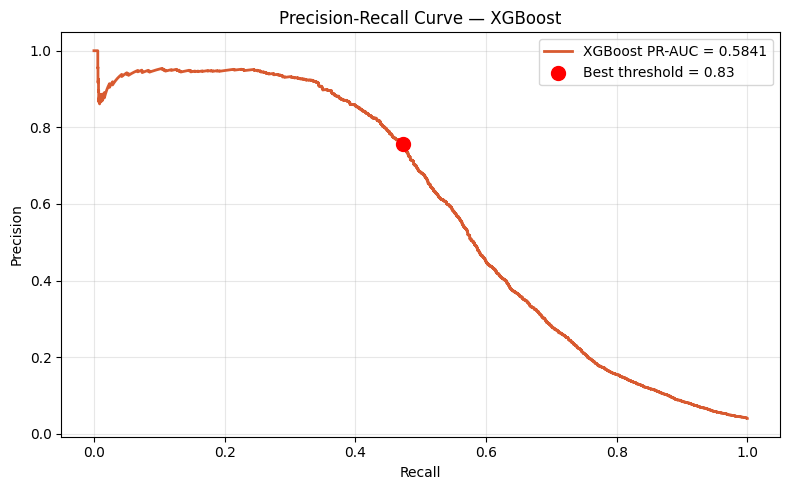

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(pr_rec, pr_prec, color='#D85A30', lw=2,
         label=f'XGBoost PR-AUC = {auc(pr_rec, pr_prec):.4f}')
plt.scatter(pr_rec[best_idx], pr_prec[best_idx],
            color='red', s=100, zorder=5,
            label=f'Best threshold = {best_threshold_xgb:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/xgb_pr_curve.png', dpi=150)
plt.show()

In [22]:
joblib.dump(xgb_best, '../models/xgboost_best.pkl')
joblib.dump({'xgb_threshold': best_threshold_xgb}, '../models/xgb_threshold.pkl')

['../models/xgb_threshold.pkl']

LightGBM (Default)

In [24]:
lgb_default = lgb.LGBMClassifier(
                    n_estimators = 300,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=spw,
                    random_state=42,
                    n_jobs=-1,
                    verbosity=-1
)
lgb_default.fit(X_train_raw , y_train_raw , eval_set = [(X_val , y_val)])

lgb_default_metrics = evaluate_model(lgb_default , X_val , y_val , model_name = 'LightGBM Default' , threshold = 0.5)
lgb_default_metrics

Model: LightGBM Default , Threshold: 0.5
Precision Recall AUC: 0.5675
F1 score: 0.3878
Precision: 0.2684
Recall:    0.6987
FPR:       0.0801
8.01% legitimate transactions blocked

Confusion Matrix:
  TP: 2,498  FP: 6,809
  FN: 1,077  TN: 78,197


{'model_name': 'LightGBM Default',
 'threshold': 0.5,
 'pr_auc': 0.5674706151287344,
 'f1': 0.3878279770222015,
 'precision': 0.26840012893521004,
 'recall': 0.6987412587412587,
 'fpr': np.float64(0.08010022821918453),
 'tp': np.int64(2498),
 'fp': np.int64(6809),
 'fn': np.int64(1077),
 'tn': np.int64(78197)}

LightGBM Optuna Hyperparameter tuning

In [25]:
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight':  spw,
        'random_state':      42,
        'n_jobs':            -1,
        'verbosity':         -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_raw, y_train_raw,
        eval_set=[(X_val, y_val)])

    proba = model.predict_proba(X_val)[:, 1]
    pr_prec, pr_rec, _ = precision_recall_curve(y_val, proba)
    return auc(pr_rec, pr_prec)

study_lgb = optuna.create_study(
    direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

study_lgb.enqueue_trial({
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0,
    'reg_lambda': 0
})

print("Running Optuna for LightGBM (50 trials)...")
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM PR-AUC: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

[I 2026-06-10 14:24:15,701] A new study created in memory with name: no-name-ff9ceaac-981e-4e65-9951-28ed6542cee7


Running Optuna for LightGBM (50 trials)...


Best trial: 0. Best value: 0.567471:   2%|▏         | 1/50 [00:05<04:41,  5.74s/it]

[I 2026-06-10 14:24:21,439] Trial 0 finished with value: 0.5674706151287344 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0, 'reg_lambda': 0}. Best is trial 0 with value: 0.5674706151287344.


Best trial: 1. Best value: 0.567784:   4%|▍         | 2/50 [00:13<05:42,  7.14s/it]

...

[I 2026-06-10 14:35:14,302] Trial 47 finished with value: 0.5579925262835816 and parameters: {'n_estimators': 266, 'max_depth': 10, 'learning_rate': 0.017596500767757935, 'num_leaves': 82, 'subsample': 0.942092895718158, 'colsample_bytree': 0.8877218742633766, 'min_child_samples': 32, 'reg_alpha': 4.599929700123185, 'reg_lambda': 0.44280561057337636}. Best is trial 31 with value: 0.5790912367327505.


Best trial: 31. Best value: 0.579091:  98%|█████████▊| 49/50 [11:17<00:22, 22.40s/it]

[I 2026-06-10 14:35:32,747] Trial 48 finished with value: 0.5734177364060207 and parameters: {'n_estimators': 242, 'max_depth': 8, 'learning_rate': 0.05733402741892958, 'num_leaves': 104, 'subsample': 0.8832653238870997, 'colsample_bytree': 0.8519238106195164, 'min_child_samples': 42, 'reg_alpha': 3.955360305358405, 'reg_lambda': 0.16081156685359277}. Best is trial 31 with value: 0.5790912367327505.


Best trial: 31. Best value: 0.579091: 100%|██████████| 50/50 [11:44<00:00, 14.08s/it]

[I 2026-06-10 14:35:59,710] Trial 49 finished with value: 0.5720338476031335 and parameters: {'n_estimators': 356, 'max_depth': 9, 'learning_rate': 0.09567611628048091, 'num_leaves': 116, 'subsample': 0.855008650200686, 'colsample_bytree': 0.9584360616515396, 'min_child_samples': 40, 'reg_alpha': 3.532985663862894, 'reg_lambda': 0.26758808168939824}. Best is trial 31 with value: 0.5790912367327505.

Best LightGBM PR-AUC: 0.5791
Best params: {'n_estimators': 318, 'max_depth': 10, 'learning_rate': 0.043823623405145215, 'num_leaves': 103, 'subsample': 0.952794255267134, 'colsample_bytree': 0.8616152249162835, 'min_child_samples': 27, 'reg_alpha': 4.5404725255009195, 'reg_lambda': 0.016821023858847595}


In [26]:
best_lgb_params = study_lgb.best_params
best_lgb_params.update({
    'scale_pos_weight': spw,
    'random_state':     42,
    'n_jobs':           -1,
    'verbosity':        -1
})

lgb_best = lgb.LGBMClassifier(**best_lgb_params)
lgb_best.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val, y_val)]
)

lgb_best_metrics = evaluate_model(
    lgb_best, X_val, y_val,
    model_name="LightGBM Optuna",
    threshold=0.5
)

# Overfit check
train_lgb_metrics = evaluate_model(
    lgb_best, X_train_raw, y_train_raw,
    model_name="LightGBM Optuna (TRAIN)",
    threshold=0.5
)

print(f"\nOverfit gap: {train_lgb_metrics['pr_auc'] - lgb_best_metrics['pr_auc']:.4f}")

Model: LightGBM Optuna , Threshold: 0.5
Precision Recall AUC: 0.5791
F1 score: 0.4409
Precision: 0.3255
Recall:    0.6828
FPR:       0.0595
5.95% legitimate transactions blocked

Confusion Matrix:
  TP: 2,441  FP: 5,058
  FN: 1,134  TN: 79,948
Model: LightGBM Optuna (TRAIN) , Threshold: 0.5
Precision Recall AUC: 0.8400
F1 score: 0.5317
Precision: 0.3725
Recall:    0.9283
FPR:       0.0548
5.48% legitimate transactions blocked

Confusion Matrix:
  TP: 11,129  FP: 18,748
  FN: 859  TN: 323,588

Overfit gap: 0.2609


Best Threshold for LighGBM

In [27]:
proba_lgb = lgb_best.predict_proba(X_val)[:, 1]
pr_prec_lgb, pr_rec_lgb, thresholds_lgb = precision_recall_curve(y_val, proba_lgb)

f1_scores_lgb = 2 * (pr_prec_lgb * pr_rec_lgb) / (pr_prec_lgb + pr_rec_lgb + 1e-8)
best_idx_lgb  = f1_scores_lgb.argmax()
best_threshold_lgb = thresholds_lgb[best_idx_lgb]

lgb_best_metrics_thresh = evaluate_model(
    lgb_best, X_val, y_val,
    model_name="LightGBM Optuna (best threshold)",
    threshold=best_threshold_lgb
)
lgb_best_metrics_thresh

Model: LightGBM Optuna (best threshold) , Threshold: 0.8323679396566854
Precision Recall AUC: 0.5791
F1 score: 0.5650
Precision: 0.6776
Recall:    0.4845
FPR:       0.0097
0.97% legitimate transactions blocked

Confusion Matrix:
  TP: 1,732  FP: 824
  FN: 1,843  TN: 84,182


{'model_name': 'LightGBM Optuna (best threshold)',
 'threshold': np.float64(0.8323679396566854),
 'pr_auc': 0.5790912367327505,
 'f1': 0.5649975534170608,
 'precision': 0.6776212832550861,
 'recall': 0.4844755244755245,
 'fpr': np.float64(0.009693433404700845),
 'tp': np.int64(1732),
 'fp': np.int64(824),
 'fn': np.int64(1843),
 'tn': np.int64(84182)}

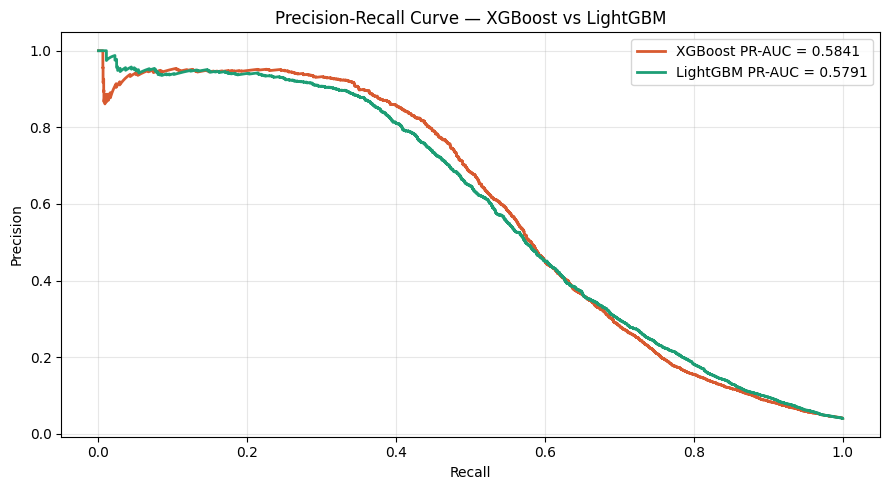

In [28]:
# Overlay PR curves
proba_xgb = xgb_best.predict_proba(X_val)[:, 1]
pr_prec_xgb, pr_rec_xgb, _ = precision_recall_curve(y_val, proba_xgb)

plt.figure(figsize=(9, 5))
plt.plot(pr_rec_xgb, pr_prec_xgb, color='#D85A30', lw=2,
         label=f'XGBoost PR-AUC = {auc(pr_rec_xgb, pr_prec_xgb):.4f}')
plt.plot(pr_rec_lgb, pr_prec_lgb, color='#1D9E75', lw=2,
         label=f'LightGBM PR-AUC = {auc(pr_rec_lgb, pr_prec_lgb):.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost vs LightGBM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/xgb_lgb_pr_curve.png', dpi=150)
plt.show()

In [29]:
joblib.dump(lgb_best, '../models/lightgbm_best.pkl')
joblib.dump({'lgb_threshold': best_threshold_lgb}, '../models/lgb_threshold.pkl')

['../models/lgb_threshold.pkl']

FINAL COMPARISION OF MODELS

In [30]:
results = pd.DataFrame([
    xgb_default_metrics,
    xgb_best_metrics,
    xgb_best_metrics_thresh,
    lgb_default_metrics,
    lgb_best_metrics,
    lgb_best_metrics_thresh
])

cols = ['model_name','threshold','pr_auc','f1','precision','recall','fpr']
print("\n" + results[cols].to_string(index=False))


                      model_name  threshold   pr_auc       f1  precision   recall      fpr
           XGBoost Default (raw)   0.500000 0.566373 0.427116   0.311276 0.680280 0.063301
                  XGBoost Optuna   0.500000 0.584108 0.505896   0.431133 0.612028 0.033962
  XGBoost Optuna(Best threshold)   0.829377 0.584108 0.581411   0.755705 0.472448 0.006423
                LightGBM Default   0.500000 0.567471 0.387828   0.268400 0.698741 0.080100
                 LightGBM Optuna   0.500000 0.579091 0.440852   0.325510 0.682797 0.059502
LightGBM Optuna (best threshold)   0.832368 0.579091 0.564998   0.677621 0.484476 0.009693


In [31]:
results[cols].to_csv('../reports/model_comparison.csv', index=False)